# WeatherJEPA — Kaggle Training

Clones the latest code from GitHub, downloads the ERA5 database, trains the JEPA model, and visualizes embeddings.

In [16]:
# ============================================================
# Config — change these, not the cells below
# ============================================================
GITHUB_REPO = "https://github.com/zariqq/weather-forecast.git"
PROJECT_DIR = "/kaggle/working/project"

PLACE = "Lidar(Tomsk)"
DB_PATH = "/kaggle/working/data.db"

TRAIN_START, TRAIN_END = "2009-01-01", "2021-12-31"
EVAL_START, EVAL_END   = "2022-01-01", "2023-12-31"

CTX_LEN = 8           # 8 * 1h = 8h lookback (native cadence = hourly)
EMBED_DIM = 64        # 16/32/64/128 — sweep this for leaderboard
EPOCHS = 15
EVAL_EVERY = 1        # evaluate every N epochs

# Loss weights — increase jepa_weight if eval RMSE plateaus early
JEPA_WEIGHT = 1.0
FORECAST_WEIGHT = 1.0

In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU — set Settings > Accelerator to GPU T4 x2 or P100, then restart.")

CUDA available: True
GPU: Tesla T4


## 1. Clone latest code from GitHub

In [13]:
import os, shutil

if os.path.exists(PROJECT_DIR):
    shutil.rmtree(PROJECT_DIR)

!git clone {GITHUB_REPO} {PROJECT_DIR}
%cd {PROJECT_DIR}
!git log --oneline -3

Cloning into '/kaggle/working/project'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 45 (delta 16), reused 40 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (45/45), 497.10 KiB | 14.20 MiB/s, done.
Resolving deltas: 100% (16/16), done.
/kaggle/working/project
94692e0 (HEAD -> main, origin/main, origin/HEAD) update: eval loss
c9a6a86 remove: mps device
b107512 kaggle server ipynb


## 2. Install dependencies

In [14]:
!grep -vi "^torch" {PROJECT_DIR}/requirements.txt > /tmp/requirements_no_torch.txt || true
!pip install -q -r /tmp/requirements_no_torch.txt
print("Dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.3/133.3 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.3/224.3 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.7/323.7 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 85.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 3. Download ERA5 database (~2.7 GB, cached after first run)

In [15]:
import sys
sys.path.insert(0, PROJECT_DIR)

from download_data import ensure_db

DB_PATH = ensure_db(DB_PATH)
print("DB ready at:", DB_PATH)

[download_data] /kaggle/working/data.db not found, downloading Drive folder to /kaggle/working/.drive_cache (this only needs to happen once)...


Retrieving folder contents


Processing file 1MzmrgQgVMKGBD4k0cz3fssjv_sWboVle data-challenge.db
Processing file 1IlUg2g9LF9aPsah6QVckroPV-bXMrDse pylidlight.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1MzmrgQgVMKGBD4k0cz3fssjv_sWboVle
From (redirected): https://drive.google.com/uc?id=1MzmrgQgVMKGBD4k0cz3fssjv_sWboVle&confirm=t&uuid=01781327-5524-400b-a6aa-45f7944b908b
To: /kaggle/working/.drive_cache/data-challenge.db
100%|██████████| 2.68G/2.68G [00:21<00:00, 126MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1IlUg2g9LF9aPsah6QVckroPV-bXMrDse
To: /kaggle/working/.drive_cache/pylidlight.zip
100%|██████████| 311k/311k [00:00<00:00, 63.9MB/s]
Download completed


[download_data] copied /kaggle/working/.drive_cache/data-challenge.db -> /kaggle/working/data.db
DB ready at: /kaggle/working/data.db


## 4. Train

In [17]:
!python {PROJECT_DIR}/train.py \
  --db {DB_PATH} --place "{PLACE}" \
  --train-start {TRAIN_START} --train-end {TRAIN_END} \
  --eval-start {EVAL_START} --eval-end {EVAL_END} \
  --ctx-len {CTX_LEN} --embed-dim {EMBED_DIM} --epochs {EPOCHS} \
  --jepa-weight {JEPA_WEIGHT} --forecast-weight {FORECAST_WEIGHT} \
  --ckpt /kaggle/working/weather_jepa_last.pt \
  --ckpt-best /kaggle/working/weather_jepa.pt \
  --metrics-out /kaggle/working/rmse_metrics.json \
  --eval-every {EVAL_EVERY}

/kaggle/working/project/dblayer/consts.py:24: SyntaxWarning: invalid escape sequence '\c'
  return "Temperature", "$C^{\circ}$"
/kaggle/working/project/dblayer/consts.py:30: SyntaxWarning: invalid escape sequence '\c'
  return "Wind Direction", "$^{\circ}$"
[download_data] found existing DB at /kaggle/working/data.db, skipping download
using device: cuda
[dataset] Lidar(Tomsk): 123769 timesteps, detected native cadence = 3600s (1.00h), 0.0% of intervals look like gaps
closed
train samples: 113922, eval samples: 9805, levels: 37
epoch 000  jepa=0.15400  fcst_3h=0.06592  fcst_6h=0.07772 | eval RMSE_3h=0.00024  RMSE_6h=0.00029  (avg=0.00027) *
epoch 001  jepa=0.14907  fcst_3h=0.03153  fcst_6h=0.04487 | eval RMSE_3h=0.00023  RMSE_6h=0.00028  (avg=0.00025) *
epoch 002  jepa=0.15912  fcst_3h=0.02619  fcst_6h=0.04007 | eval RMSE_3h=0.00020  RMSE_6h=0.00026  (avg=0.00023) *
epoch 003  jepa=0.15257  fcst_3h=0.02346  fcst_6h=0.03746 | eval RMSE_3h=0.00020  RMSE_6h=0.00026  (avg=0.00023) *
epoch 

## 5. Inspect results

Mean RMSE by horizon (kg/kg):
  3h: 0.000177
  6h: 0.000241
Embedding dim: 64
Eval range: ['2022-01-01', '2023-12-31']


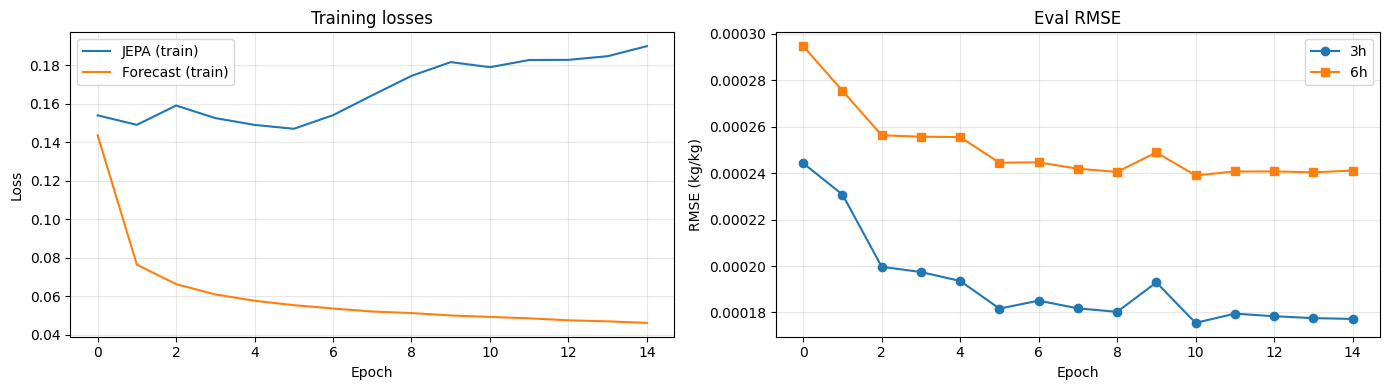

In [18]:
import json

with open("/kaggle/working/rmse_metrics.json") as f:
    metrics = json.load(f)

print("Mean RMSE by horizon (kg/kg):")
for h, v in metrics["rmse_mean_by_horizon"].items():
    print(f"  {h}h: {v:.6f}")
print(f"Embedding dim: {metrics['embed_dim']}")
print(f"Eval range: {metrics['eval_range']}")
if metrics.get("best_eval_rmse_mean"):
    print(f"Best eval RMSE (avg): {metrics['best_eval_rmse_mean']:.6f}")

# Quick loss plot
import matplotlib.pyplot as plt
history = metrics["loss_history"]
epochs = [h["epoch"] for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(epochs, [h["jepa_loss"] for h in history], label="JEPA (train)")
ax1.plot(epochs, [h["forecast_loss"] for h in history], label="Forecast (train)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training losses")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Per-horizon eval RMSE (may not exist for every epoch if eval_every > 1)
eval_3h = [(h["epoch"], h["eval_rmse_3h"]) for h in history if "eval_rmse_3h" in h]
eval_6h = [(h["epoch"], h["eval_rmse_6h"]) for h in history if "eval_rmse_6h" in h]
if eval_3h:
    ax2.plot([e[0] for e in eval_3h], [e[1] for e in eval_3h], "o-", label="3h")
    ax2.plot([e[0] for e in eval_6h], [e[1] for e in eval_6h], "s-", label="6h")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("RMSE (kg/kg)")
ax2.set_title("Eval RMSE")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/loss_curves.png", dpi=100)
plt.show()

## 6. Embedding visualization (PCA / t-SNE / cosine similarity)

In [ ]:
!python {PROJECT_DIR}/visualize_embeddings.py \
  --db {DB_PATH} --place "{PLACE}" \
  --ckpt /kaggle/working/weather_jepa.pt \
  --eval-start {EVAL_START} --eval-end {EVAL2_END} \
  --horizon 3 \
  --out-prefix /kaggle/working/embeddings

from IPython.display import Image, display
display(Image("/kaggle/working/embeddings_pca.png"))
display(Image("/kaggle/working/embeddings_tsne.png"))
display(Image("/kaggle/working/embeddings_cosine_sim.png"))

[download_data] found existing DB at /kaggle/working/data.db, skipping download
using device: cuda
Traceback (most recent call last):
  File "/kaggle/working/project/visualize_embeddings.py", line 167, in <module>
    main()
  File "/kaggle/working/project/visualize_embeddings.py", line 63, in main
    ckpt = torch.load(args.ckpt, map_location=device)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 1548, in load
    raise pickle.UnpicklingError(_get_wo_message(str(e))) from None
_pickle.UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it o

FileNotFoundError: No such file or directory: '/kaggle/working/embeddings_pca.png'

FileNotFoundError: No such file or directory: '/kaggle/working/embeddings_pca.png'

<IPython.core.display.Image object>

FileNotFoundError: No such file or directory: '/kaggle/working/embeddings_tsne.png'

FileNotFoundError: No such file or directory: '/kaggle/working/embeddings_tsne.png'

<IPython.core.display.Image object>

FileNotFoundError: No such file or directory: '/kaggle/working/embeddings_cosine_sim.png'

FileNotFoundError: No such file or directory: '/kaggle/working/embeddings_cosine_sim.png'

<IPython.core.display.Image object>